# Exploration des données (EDA) — Credit Risk Dataset

Analyse exploratoire en vue d'un projet de Machine Learning de **scoring crédit** (prédiction de défaut de paiement, variable cible `loan_status`).


## 1. Chargement des librairies et du dataset

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100

df = pd.read_csv("C:\\Users\\DELL\\Desktop\\credit_risk_dataset.csv")
df.shape
df.head(10)


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4
5,21,9900,OWN,2.0,VENTURE,A,2500,7.14,1,0.25,N,2
6,26,77100,RENT,8.0,EDUCATION,B,35000,12.42,1,0.45,N,3
7,24,78956,RENT,5.0,MEDICAL,B,35000,11.11,1,0.44,N,4
8,24,83000,RENT,8.0,PERSONAL,A,35000,8.90,1,0.42,N,2
9,21,10000,OWN,6.0,VENTURE,D,1600,14.74,1,0.16,N,3


**Renommer les noms des différentes variables en français**

In [3]:
rename = {
    'person_age': 'age_personne',
    'person_income': 'revenu_annuel',
    'person_home_ownership': 'statut_logement',
    'person_emp_length': 'anciennete_emploi',
    'loan_intent': 'motif_pret',
    'loan_grade': 'note_pret',
    'loan_amnt': 'montant_pret',
    'loan_int_rate': 'taux_interet',
    'loan_status': 'statut_defaut',          # variable cible : 1 = défaut, 0 = pas de défaut
    'loan_percent_income': 'pret_pourcentage_revenu',
    'cb_person_default_on_file': 'historique_defaut',
    'cb_person_cred_hist_length': 'anciennete_credit'
}

df = df.rename(columns=rename)

print(f"Shape du dataset : {df.shape[0]} lignes, {df.shape[1]} colonnes")
df.head()

Shape du dataset : 32581 lignes, 12 colonnes


,age_personne,revenu_annuel,statut_logement,anciennete_emploi,motif_pret,note_pret,montant_pret,taux_interet,statut_defaut,pret_pourcentage_revenu,historique_defaut,anciennete_credit
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


## 2. Vue d'ensemble du dataset

In [4]:
print(f"Nombre de lignes : {df.shape[0]}")
print(f"Nombre de colonnes : {df.shape[1]}")
df.info()


Nombre de lignes : 32581
Nombre de colonnes : 12
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age_personne             32581 non-null  int64  
 1   revenu_annuel            32581 non-null  int64  
 2   statut_logement          32581 non-null  object 
 3   anciennete_emploi        31686 non-null  float64
 4   motif_pret               32581 non-null  object 
 5   note_pret                32581 non-null  object 
 6   montant_pret             32581 non-null  int64  
 7   taux_interet             29465 non-null  float64
 8   statut_defaut            32581 non-null  int64  
 9   pret_pourcentage_revenu  32581 non-null  float64
 10  historique_defaut        32581 non-null  object 
 11  anciennete_credit        32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [5]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age_personne,32581.0,NaN,NaN,NaN,27.7346,6.348078,20.0,23.0,26.0,30.0,144.0
revenu_annuel,32581.0,NaN,NaN,NaN,66074.84847,61983.119168,4000.0,38500.0,55000.0,79200.0,6000000.0
statut_logement,32581,4,RENT,16446,NaN,NaN,NaN,NaN,NaN,NaN,NaN
anciennete_emploi,31686.0,NaN,NaN,NaN,4.789686,4.14263,0.0,2.0,4.0,7.0,123.0
motif_pret,32581,6,EDUCATION,6453,NaN,NaN,NaN,NaN,NaN,NaN,NaN
note_pret,32581,7,A,10777,NaN,NaN,NaN,NaN,NaN,NaN,NaN
montant_pret,32581.0,NaN,NaN,NaN,9589.371106,6322.086646,500.0,5000.0,8000.0,12200.0,35000.0
taux_interet,29465.0,NaN,NaN,NaN,11.011695,3.240459,5.42,7.9,10.99,13.47,23.22
statut_defaut,32581.0,NaN,NaN,NaN,0.218164,0.413006,0.0,0.0,0.0,0.0,1.0
pret_pourcentage_revenu,32581.0,NaN,NaN,NaN,0.170203,0.106782,0.0,0.09,0.15,0.23,0.83


### Dictionnaire des variables

| Variable | Type | Description |
|---|---|---|
| age_personne | int | Âge de l'emprunteur |
| revenu_annuel | int | Revenu annuel |
| statut_logement | catégorielle | Statut logement (RENT/OWN/MORTGAGE/OTHER) |
| anciennete_emploi | float | Ancienneté d'emploi (années) |
| motif_pret| catégorielle | Motif du prêt |
| note_pret | catégorielle | Note de risque du prêt (A à G) |
| montant_pret| int | Montant du prêt |
| taux_interet| float | Taux d'intérêt (%) |
|  statut_defaut | binaire | **Variable cible** : 1 = défaut, 0 = pas de défaut |
| pret_pourcentage_revenu| float | Montant du prêt / revenu |
| historique_defaut | catégorielle | Historique de défaut (Y/N) |
| anciennete_credit | int | Longueur historique de crédit (années) |


## 3. Qualité des données

### 3.1 Valeurs manquantes

In [6]:
missing = df.isna().sum()
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({'valeurs_manquantes': missing, 'pourcentage': missing_pct}).query('valeurs_manquantes > 0')


,valeurs_manquantes,pourcentage
anciennete_emploi,895,2.75
taux_interet,3116,9.56


### 3.2 Doublons

In [7]:
n_dup = df.duplicated().sum()
pd.DataFrame([f"Le Nombre de doublons est de: {n_dup} soit ({n_dup/len(df)*100:.2f}%)"])


,0
0,Le Nombre de doublons est de: 165 soit (0.51%)


### 3.3 Valeurs aberrantes (outliers)

On repère notamment des âges incohérents (jusqu'à 144 ans) et des anciennetés d'emploi incohérentes (jusqu'à 123 ans).

In [8]:
print("Lignes avec un âge > 90 ans :")
display(df[df.age_personne > 90][['age_personne','anciennete_emploi','revenu_annuel','statut_defaut']])

print("\nLignes avec une ancienneté d'emploi > 60 ans :")
display(df[df.anciennete_emploi > 60][['age_personne','anciennete_emploi','revenu_annuel','statut_defaut']])


Lignes avec un âge > 90 ans :


,age_personne,anciennete_emploi,revenu_annuel,statut_defaut
81,144,4.0,250000,0
183,144,4.0,200000,0
575,123,2.0,80004,0
747,123,7.0,78000,0
32297,144,12.0,6000000,0
32416,94,1.0,24000,0



Lignes avec une ancienneté d'emploi > 60 ans :


,age_personne,anciennete_emploi,revenu_annuel,statut_defaut
0,22,123.0,59000,1
210,21,123.0,192000,0


## 4. Variable cible : `loan_status`

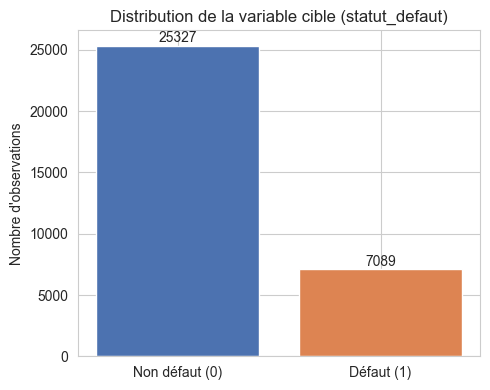

In [67]:
target_counts = df['statut_defaut'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(5,4))
labels = ['Non défaut (0)', 'Défaut (1)']
colors = ['#4C72B0', '#DD8452']
ax.bar(labels, target_counts.values, color=colors)
for i, v in enumerate(target_counts.values):
    ax.text(i, v + 300, f"{v}", ha='center', fontsize=10)

ax.set_title("Distribution de la variable cible (statut_defaut)")
ax.set_ylabel("Nombre d'observations")
plt.tight_layout()
plt.show()

## 5. Distribution des variables numériques

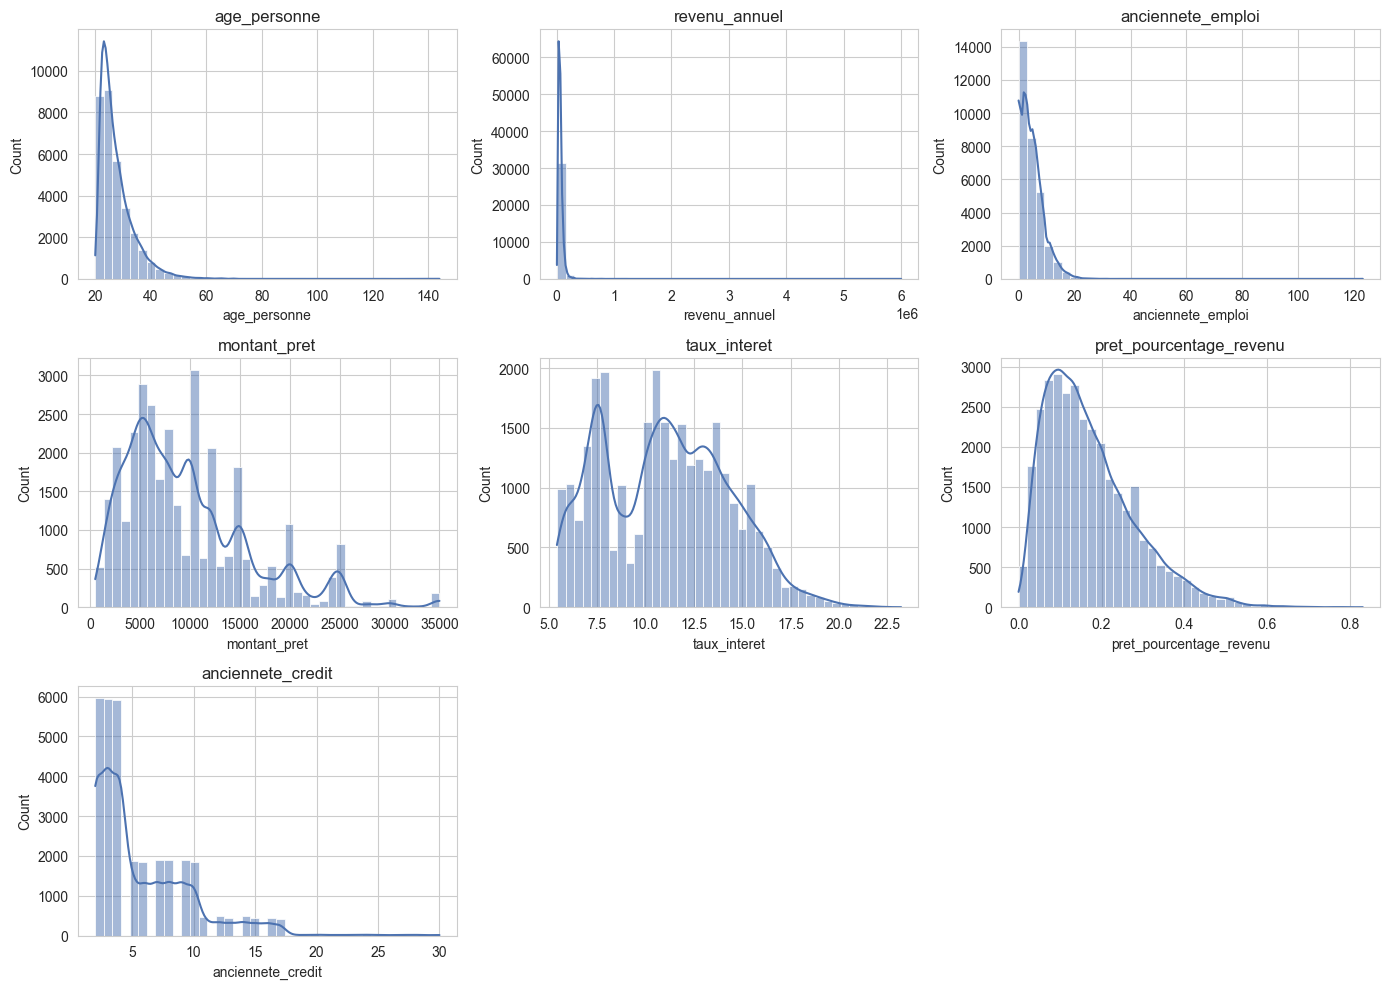

In [10]:
num_cols = ['age_personne','revenu_annuel','anciennete_emploi','montant_pret',
            'taux_interet','pret_pourcentage_revenu','anciennete_credit']

fig, axes = plt.subplots(3, 3, figsize=(14,10))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    sns.histplot(df[col].dropna(), bins=40, ax=axes[i], color='#4C72B0', kde=True)
    axes[i].set_title(col)
for j in range(len(num_cols), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()


## 6. Détection visuelle des outliers

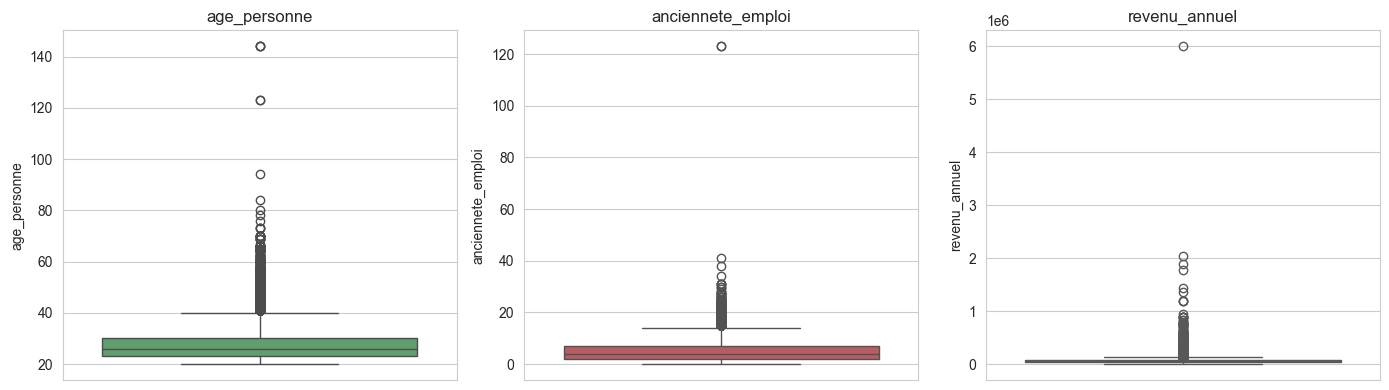

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(14,4))
sns.boxplot(y=df['age_personne'], ax=axes[0], color='#55A868'); axes[0].set_title('age_personne')
sns.boxplot(y=df['anciennete_emploi'], ax=axes[1], color='#C44E52'); axes[1].set_title('anciennete_emploi')
sns.boxplot(y=df['revenu_annuel'], ax=axes[2], color='#8172B2'); axes[2].set_title('revenu_annuel')
plt.tight_layout()
plt.show()


## 7. Variables catégorielles

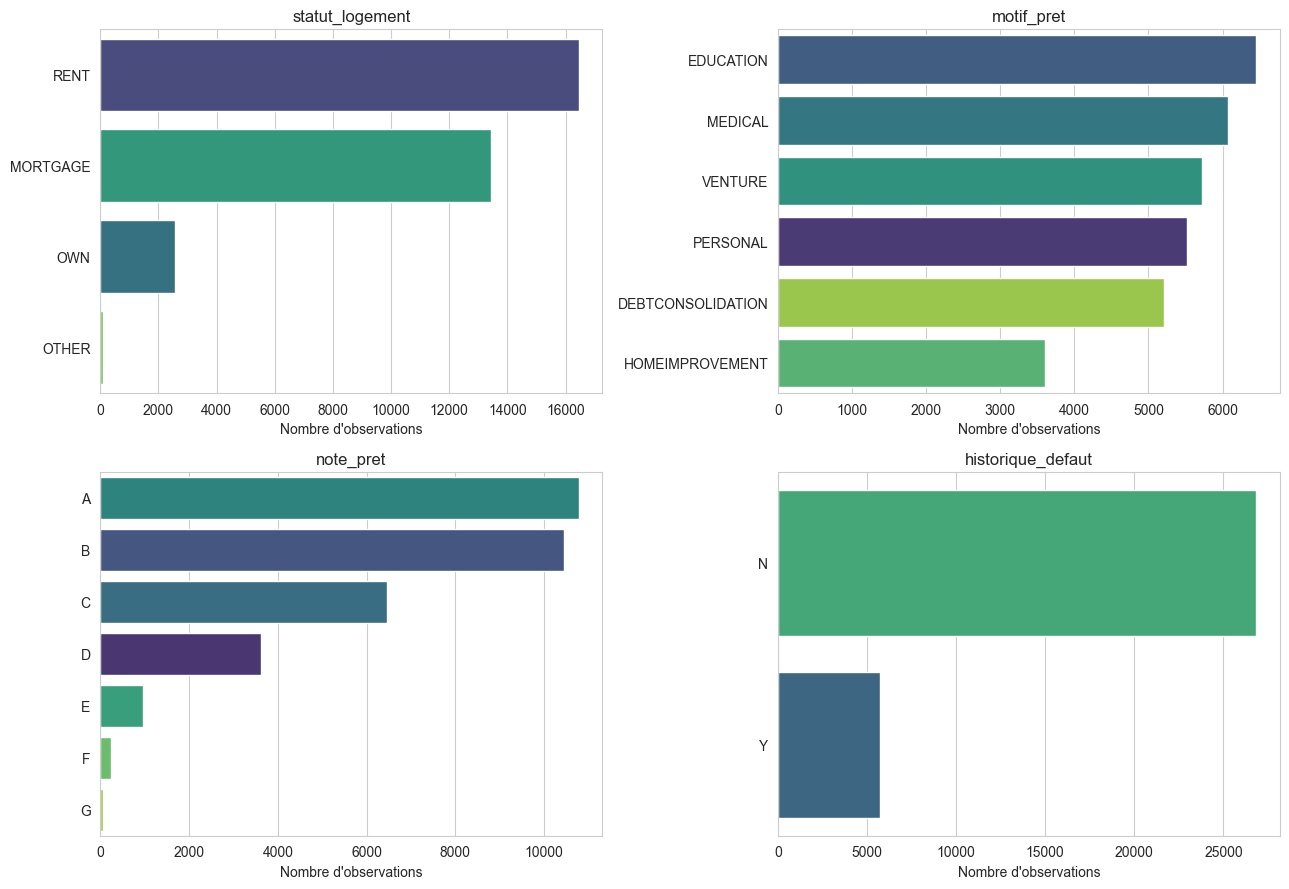

In [12]:
cat_cols = ['statut_logement', 'motif_pret', 'note_pret', 'historique_defaut']

fig, axes = plt.subplots(2, 2, figsize=(13,9))
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    order = df[col].value_counts().index
    sns.countplot(y=df[col], order=order, hue=df[col], legend=False, ax=axes[i], palette='viridis')
    axes[i].set_title(col)
    axes[i].set_xlabel("Nombre d'observations")
    axes[i].set_ylabel("")
plt.tight_layout()
plt.show()


## 8. Taux de défaut par variable catégorielle

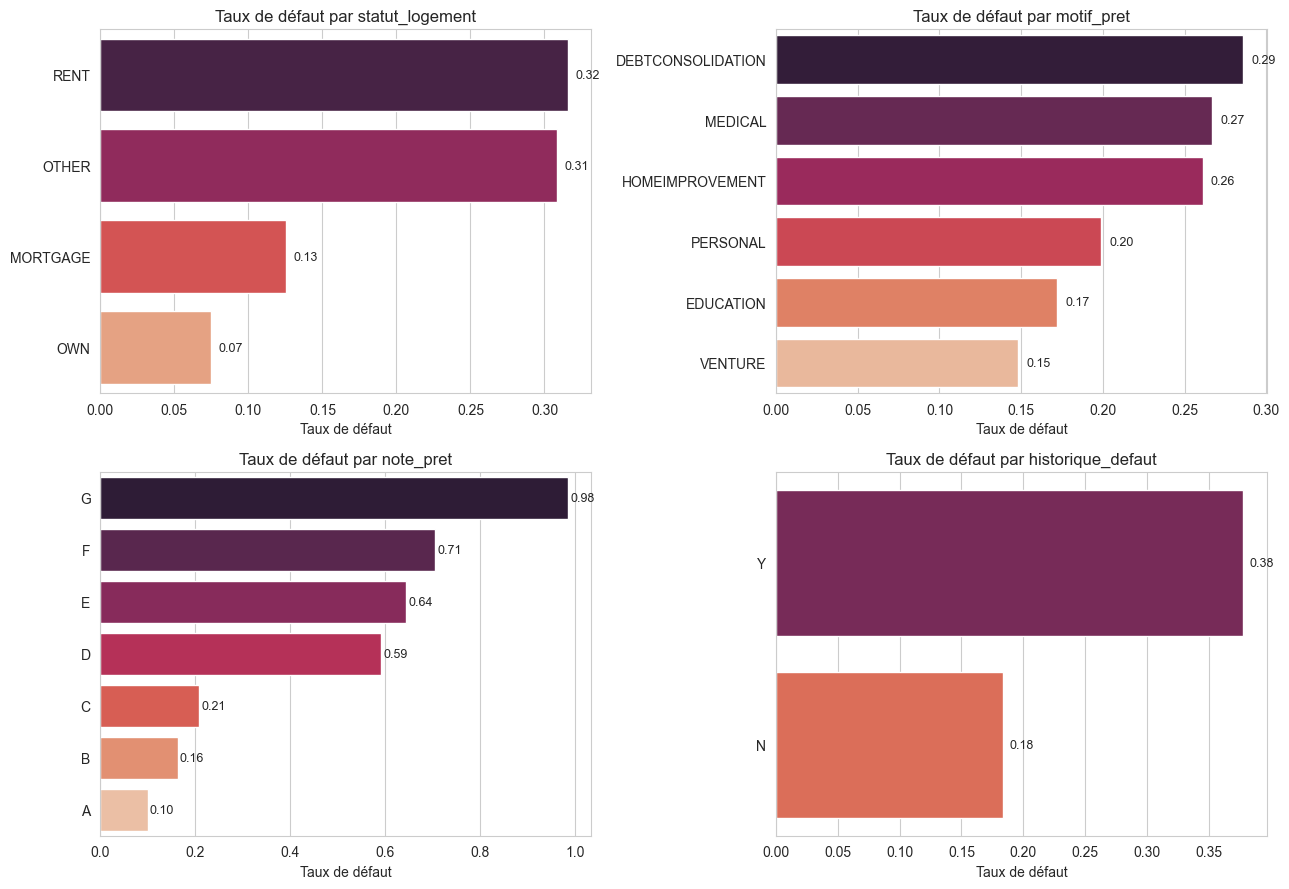

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(13,9))
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    rate = df.groupby(col)['statut_defaut'].mean().sort_values(ascending=False)
    sns.barplot(x=rate.values, y=rate.index, hue=rate.index, legend=False, ax=axes[i], palette='rocket')
    axes[i].set_title(f"Taux de défaut par {col}")
    axes[i].set_xlabel("Taux de défaut")
    axes[i].set_ylabel("")
    for j, v in enumerate(rate.values):
        axes[i].text(v + 0.005, j, f"{v:.2f}", va='center', fontsize=9)
plt.tight_layout()
plt.show()


## 9. Corrélations entre variables numériques

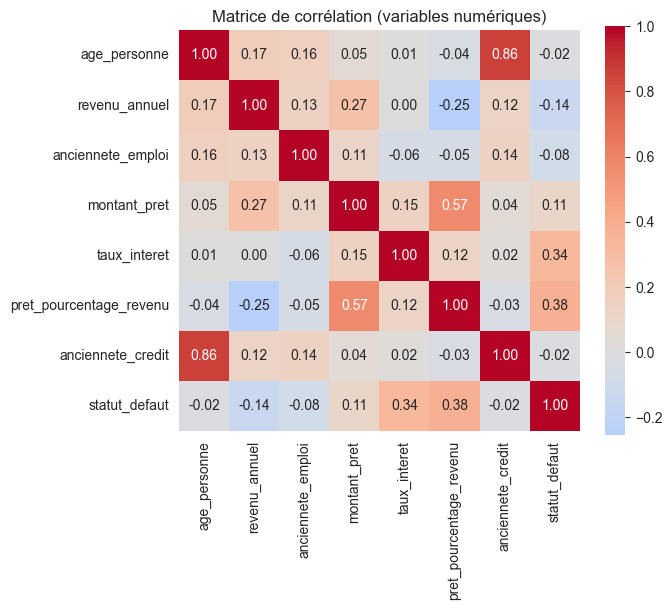

In [14]:
plt.figure(figsize=(7,6))
corr = df[num_cols + ['statut_defaut']].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', center=0, square=True)
plt.title("Matrice de corrélation (variables numériques)")
plt.tight_layout()
plt.show()


## 10. Taux d'intérêt selon la note de crédit

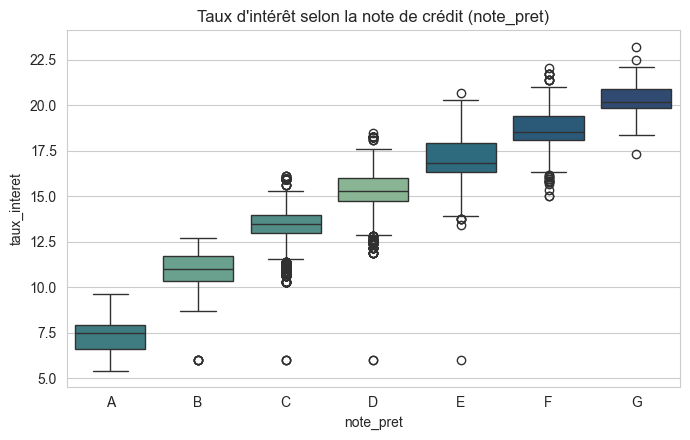

In [15]:
plt.figure(figsize=(7,4.5))
order = sorted(df['note_pret'].dropna().unique())
sns.boxplot(x='note_pret', y='taux_interet', data=df, hue='note_pret', legend=False, order=order, palette='crest')
plt.title("Taux d'intérêt selon la note de crédit (note_pret)")
plt.tight_layout()
plt.show()


## 11. Synthèse — recommandations pour la suite du projet

- **Valeurs manquantes** : imputer `person_emp_length` et `loan_int_rate` (médiane/mode ou modèle)
- **Outliers** : supprimer ou plafonner `person_age` (> 90 ans) et `person_emp_length` (> 60 ans)
- **Doublons** : supprimer les doublons stricts identifiés en section 3.2
- **Encodage** : One-Hot Encoding pour les variables catégorielles nominales ; encodage ordinal pour `loan_grade` (A→G)
- **Déséquilibre de classes** : `class_weight`, SMOTE, ou ajustement du seuil de décision
- **Transformation** : envisager une transformation log sur `person_income` et `loan_amnt`
- **Multicolinéarité** : surveiller la redondance entre `person_age` et `cb_person_cred_hist_length`


---
#  Nettoyage et prétraitement des données

Cette section applique les traitements identifiés lors de l'EDA, avec les méthodes adaptées à ce dataset (variables mixtes numériques/catégorielles, classes déséquilibrées, quelques outliers extrêmes et peu de valeurs manquantes).

## 12. Suppression des doublons

In [16]:
print(f"Avant suppression : {df.shape[0]} lignes")
df = df.drop_duplicates().reset_index(drop=True)
print(f"Après suppression : {df.shape[0]} lignes")


Avant suppression : 32581 lignes
Après suppression : 32416 lignes


## 13. Traitement des valeurs aberrantes (outliers)

**Méthode choisie : suppression ciblée par seuil métier** plutôt que la méthode IQR globale.
Justification : `age_personne` (>90 ans) et `anciennete_emploi` (>60 ans) sont des erreurs de saisie évidentes et concernent un nombre de lignes infime (<10) — les supprimer ne fait perdre aucune information utile, contrairement à un plafonnement IQR qui aurait tronqué des valeurs légitimes plus fréquentes (ex: revenus élevés).

In [17]:
def cap_outliers_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    borne_inf = Q1 - 1.5 * IQR
    borne_sup = Q3 + 1.5 * IQR
    df[col] = df[col].clip(lower=borne_inf, upper=borne_sup)
    return df

for col in ['revenu_annuel', 'anciennete_emploi', 'age_personne']:
    df = cap_outliers_iqr(df, col)

print("Outliers restants après capping :")
for col in ['revenu_annuel', 'anciennete_emploi', 'age_personne']:
    Q1, Q3 = df[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    n = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)].shape[0]
    print(f"{col}: {n} outliers")

Outliers restants après capping :
revenu_annuel: 0 outliers
anciennete_emploi: 0 outliers
age_personne: 0 outliers


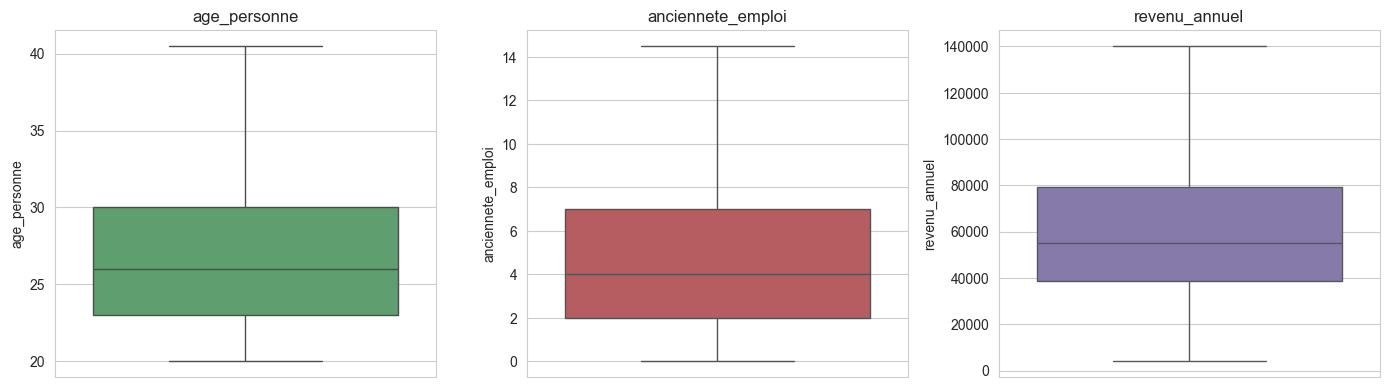

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(14,4))
sns.boxplot(y=df['age_personne'], ax=axes[0], color='#55A868'); axes[0].set_title('age_personne')
sns.boxplot(y=df['anciennete_emploi'], ax=axes[1], color='#C44E52'); axes[1].set_title('anciennete_emploi')
sns.boxplot(y=df['revenu_annuel'], ax=axes[2], color='#8172B2'); axes[2].set_title('revenu_annuel')
plt.tight_layout()
plt.show()


## 14. Traitement des valeurs manquantes

- **`anciennete_emploi`** (2.75% manquant) : imputation par la **médiane**, car la distribution est asymétrique (skewed) — la médiane est plus robuste que la moyenne face aux valeurs extrêmes.
- **`taux_interet`** (9.56% manquant) : imputation par la **médiane groupée par `note_pret`**, car le taux d'intérêt dépend fortement de la note de crédit (relation confirmée en EDA) — une imputation par groupe est plus précise qu'une médiane globale.

In [19]:
# Imputation anciennete_emploi par la médiane globale
mediane_emploi = df['anciennete_emploi'].median()
df['anciennete_emploi'] = df['anciennete_emploi'].fillna(mediane_emploi)

# Imputation taux_interet par la médiane de chaque note_pret
df['taux_interet'] = df.groupby('note_pret')['taux_interet'].transform(
    lambda x: x.fillna(x.median())
)

print("Valeurs manquantes restantes :")
print(df.isna().sum()[df.isna().sum() > 0])
print("\n Aucune valeur manquante restante" if df.isna().sum().sum() == 0 else "")


Valeurs manquantes restantes :
Series([], dtype: int64)

 Aucune valeur manquante restante


## 15. Transformation des variables numériques asymétriques

`revenu_annuel` et `montant_pret` sont fortement asymétriques à droite (confirmé en EDA). On applique une **transformation log1p** (log(1+x), qui gère les valeurs nulles) pour réduire cette asymétrie et faciliter le travail de certains modèles (régression logistique, SVM, réseaux de neurones).

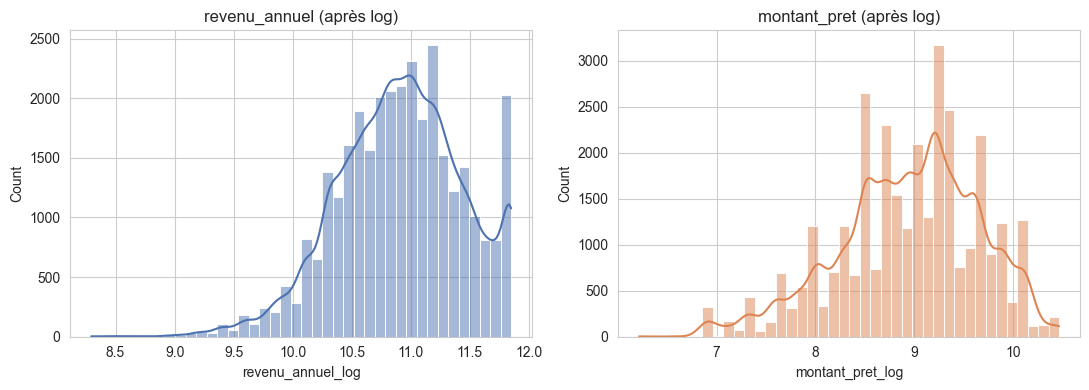

In [20]:
import numpy as np

df['revenu_annuel_log'] = np.log1p(df['revenu_annuel'])
df['montant_pret_log'] = np.log1p(df['montant_pret'])

fig, axes = plt.subplots(1, 2, figsize=(11,4))
sns.histplot(df['revenu_annuel_log'], bins=40, ax=axes[0], color='#4C72B0', kde=True)
axes[0].set_title("revenu_annuel (après log)")
sns.histplot(df['montant_pret_log'], bins=40, ax=axes[1], color='#DD8452', kde=True)
axes[1].set_title("montant_pret (après log)")
plt.tight_layout()
plt.show()


## 16. Encodage des variables catégorielles

- **`note_pret`** (A→G) : variable **ordinale** → encodage ordinal (0 à 6), car il existe un ordre naturel de risque croissant.
- **`historique_defaut`** (Y/N) : variable **binaire** → encodage 0/1.
- **`statut_logement`** et **`motif_pret`** : variables **nominales** (sans ordre) → One-Hot Encoding, pour éviter d'introduire un ordre artificiel.

In [21]:
# Encodage ordinal pour note_pret (A = risque le plus faible -> G = risque le plus élevé)
ordre_notes = ['A','B','C','D','E','F','G']
df['note_pret_encodee'] = df['note_pret'].apply(lambda x: ordre_notes.index(x))

# Encodage binaire pour historique_defaut
df['historique_defaut_encode'] = df['historique_defaut'].map({'N': 0, 'Y': 1})

# One-Hot Encoding pour les variables nominales
df = pd.get_dummies(df, columns=['statut_logement', 'motif_pret'], prefix=['logement', 'motif'], drop_first=True)

# Conversion des colonnes booléennes (True/False) en numérique (0/1)
colonnes_bool = df.select_dtypes(include='bool').columns
df[colonnes_bool] = df[colonnes_bool].astype(int)

df.head()


,age_personne,revenu_annuel,anciennete_emploi,note_pret,montant_pret,taux_interet,statut_defaut,pret_pourcentage_revenu,historique_defaut,anciennete_credit,...,note_pret_encodee,historique_defaut_encode,logement_OTHER,logement_OWN,logement_RENT,motif_EDUCATION,motif_HOMEIMPROVEMENT,motif_MEDICAL,motif_PERSONAL,motif_VENTURE
0,22.0,59000,14.5,D,35000,16.02,1,0.59,Y,3,...,3,1,0,0,1,0,0,0,1,0
1,21.0,9600,5.0,B,1000,11.14,0,0.10,N,2,...,1,0,0,1,0,1,0,0,0,0
2,25.0,9600,1.0,C,5500,12.87,1,0.57,N,3,...,2,0,0,0,0,0,0,1,0,0
3,23.0,65500,4.0,C,35000,15.23,1,0.53,N,2,...,2,0,0,0,1,0,0,1,0,0
4,24.0,54400,8.0,C,35000,14.27,1,0.55,Y,4,...,2,1,0,0,1,0,0,1,0,0


## 17. Sélection finale des variables et suppression des colonnes redondantes

In [22]:
colonnes_a_retirer = ['note_pret', 'historique_defaut']
df_final = df.drop(columns=colonnes_a_retirer)

print(f"Shape final : {df_final.shape}")
df_final.head()


Shape final : (32416, 20)


,age_personne,revenu_annuel,anciennete_emploi,montant_pret,taux_interet,statut_defaut,pret_pourcentage_revenu,anciennete_credit,revenu_annuel_log,montant_pret_log,note_pret_encodee,historique_defaut_encode,logement_OTHER,logement_OWN,logement_RENT,motif_EDUCATION,motif_HOMEIMPROVEMENT,motif_MEDICAL,motif_PERSONAL,motif_VENTURE
0,22.0,59000,14.5,35000,16.02,1,0.59,3,10.985310,10.463132,3,1,0,0,1,0,0,0,1,0
1,21.0,9600,5.0,1000,11.14,0,0.10,2,9.169623,6.908755,1,0,0,1,0,1,0,0,0,0
2,25.0,9600,1.0,5500,12.87,1,0.57,3,9.169623,8.612685,2,0,0,0,0,0,0,1,0,0
3,23.0,65500,4.0,35000,15.23,1,0.53,2,11.089821,10.463132,2,0,0,0,1,0,0,1,0,0
4,24.0,54400,8.0,35000,14.27,1,0.55,4,10.904138,10.463132,2,1,0,0,1,0,0,1,0,0


## 18. Mise à l'échelle (scaling) des variables numériques

Le **StandardScaler** (moyenne=0, écart-type=1) est appliqué aux variables numériques continues. C'est important pour les modèles sensibles à l'échelle (régression logistique, SVM, k-NN, réseaux de neurones) les modèles à base d'arbres (Random Forest, XGBoost) n'en ont pas strictement besoin, mais cela ne leur nuit pas.

 Le scaler est **ajusté uniquement sur le train** (voir section suivante) pour éviter toute fuite de données (data leakage) ici on l'illustre sur l'ensemble du dataset à titre indicatif avant le split.

In [23]:
from sklearn.preprocessing import StandardScaler

num_cols_scaling = ['anciennete_emploi', 'taux_interet', 'pret_pourcentage_revenu',
                     'anciennete_credit', 'revenu_annuel_log', 'montant_pret_log',
                     'note_pret_encodee']

scaler = StandardScaler()
df_final[num_cols_scaling] = scaler.fit_transform(df_final[num_cols_scaling])
df_final[num_cols_scaling].describe().T


,count,mean,std,min,25%,50%,75%,max
anciennete_emploi,32416.0,-8.417091e-17,1.000015,-1.259029,-0.721295,-0.183561,0.623041,2.639545
taux_interet,32416.0,-3.033660e-16,1.000015,-1.742789,-0.977229,-0.009386,0.765511,3.796634
pret_pourcentage_revenu,32416.0,1.508062e-16,1.000015,-1.593946,-0.751331,-0.189587,0.559404,6.176838
anciennete_credit,32416.0,-1.683418e-16,1.000015,-0.938982,-0.692614,-0.446246,0.539227,5.959324
revenu_annuel_log,32416.0,3.016124e-16,1.000015,-4.950468,-0.663454,0.009486,0.700004,1.780807
montant_pret_log,32416.0,1.532612e-15,1.000015,-3.832723,-0.597429,0.063369,0.662454,2.138606
note_pret_encodee,32416.0,4.383901e-18,1.000015,-1.045605,-1.045605,-0.188909,0.667787,4.094572


## 19. Séparation Train / Test et gestion du déséquilibre des classes

- Split **stratifié** (80/20) pour préserver la proportion de défauts dans les deux sous-ensembles.
- Le déséquilibre des classes (~78%/22%) est géré via `class_weight='balanced'` au niveau du modèle (préférable à un sur-échantillonnage type SMOTE à ce stade, qui doit s'appliquer uniquement sur le train pour éviter la fuite de données à faire dans le notebook de modélisation).

In [24]:
from sklearn.model_selection import train_test_split

X = df_final.drop(columns=['statut_defaut'])
y = df_final['statut_defaut']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train : {X_train.shape[0]} lignes | Test : {X_test.shape[0]} lignes")
print(f"Proportion de défauts - Train : {y_train.mean():.3f} | Test : {y_test.mean():.3f}")


Train : 25932 lignes | Test : 6484 lignes
Proportion de défauts - Train : 0.219 | Test : 0.219


## 20. Sauvegarde du dataset nettoyé

In [25]:
df_final.to_csv('credit_risk_dataset_clean.csv', index=False)
print("Dataset nettoyé sauvegardé : credit_risk_dataset_clean.csv")
print(f"Shape final prêt pour la modélisation : {df_final.shape}")


Dataset nettoyé sauvegardé : credit_risk_dataset_clean.csv
Shape final prêt pour la modélisation : (32416, 20)


---
#  Entraînement des modèles de Machine Learning

On entraîne et compare trois algorithmes complémentaires, choisis en cohérence avec l'état de l'art du credit scoring (Baesens et al. 2003 ; Lessmann et al. 2015 ; Brown & Mues 2012) :

- **Régression logistique** : modèle de référence (baseline), simple et interprétable — très utilisé en pratique dans le secteur bancaire car il permet d'expliquer facilement une décision de refus de crédit.
- **Random Forest** : méthode d'ensemble robuste, peu sensible au surapprentissage, gère bien les interactions non linéaires entre variables.
- **XGBoost** : algorithme de gradient boosting, généralement le plus performant sur les données de credit scoring selon la littérature récente (Ariza-Garzón et al. 2020 ; Ampountolas et al. 2021).

Le déséquilibre des classes (~22% de défauts) est géré via `class_weight='balanced'` (régression logistique, Random Forest) et `scale_pos_weight` (XGBoost), plutôt qu'un sur-échantillonnage, pour rester fidèle au pipeline de prétraitement déjà construit.

## 22. Import des librairies de modélisation

In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, roc_curve, confusion_matrix,
                              classification_report, ConfusionMatrixDisplay)


## 23. Modèle 1 — Régression logistique 

`class_weight='balanced'` ajuste automatiquement le poids des classes en fonction de leur fréquence, ce qui pénalise davantage les erreurs sur la classe minoritaire (les défauts) sans avoir besoin de sur-échantillonner artificiellement les données.

In [27]:
log_reg = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)

y_pred_lr = log_reg.predict(X_test)
y_proba_lr = log_reg.predict_proba(X_test)[:, 1]

print("=== Régression logistique ===")
print(classification_report(y_test, y_pred_lr, target_names=['Non défaut', 'Défaut']))
print(f"AUC : {roc_auc_score(y_test, y_proba_lr):.4f}")


=== Régression logistique ===
              precision    recall  f1-score   support

  Non défaut       0.93      0.81      0.86      5066
      Défaut       0.53      0.79      0.64      1418

    accuracy                           0.80      6484
   macro avg       0.73      0.80      0.75      6484
weighted avg       0.85      0.80      0.81      6484

AUC : 0.8719


c:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## 24. Modèle 2 — Random Forest

Un modèle d'ensemble basé sur de multiples arbres de décision, moins sensible aux outliers restants et capable de capturer des relations non linéaires entre les variables.

In [28]:
rf = RandomForestClassifier(
    n_estimators=300, max_depth=12, min_samples_leaf=5,
    class_weight='balanced', random_state=42, n_jobs=-1
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

print("=== Random Forest ===")
print(classification_report(y_test, y_pred_rf, target_names=['Non défaut', 'Défaut']))
print(f"AUC : {roc_auc_score(y_test, y_proba_rf):.4f}")


=== Random Forest ===
              precision    recall  f1-score   support

  Non défaut       0.93      0.96      0.95      5066
      Défaut       0.85      0.75      0.80      1418

    accuracy                           0.92      6484
   macro avg       0.89      0.86      0.87      6484
weighted avg       0.92      0.92      0.92      6484

AUC : 0.9300


## 25. Modèle 3 — XGBoost

`scale_pos_weight` est l'équivalent de `class_weight='balanced'` pour XGBoost : on le fixe au ratio (nombre de non-défauts / nombre de défauts) dans le jeu d'entraînement pour compenser le déséquilibre des classes.

In [29]:
ratio_classes = (y_train == 0).sum() / (y_train == 1).sum()

xgb = XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.08,
    scale_pos_weight=ratio_classes, eval_metric='logloss',
    random_state=42, n_jobs=-1
)
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)
y_proba_xgb = xgb.predict_proba(X_test)[:, 1]

print("=== XGBoost ===")
print(classification_report(y_test, y_pred_xgb, target_names=['Non défaut', 'Défaut']))
print(f"AUC : {roc_auc_score(y_test, y_proba_xgb):.4f}")


=== XGBoost ===
              precision    recall  f1-score   support

  Non défaut       0.95      0.97      0.96      5066
      Défaut       0.87      0.80      0.83      1418

    accuracy                           0.93      6484
   macro avg       0.91      0.88      0.89      6484
weighted avg       0.93      0.93      0.93      6484

AUC : 0.9517


## 26. Comparaison des modèles

On compare les trois modèles sur des métriques adaptées aux classes déséquilibrées : **précision**, **rappel**, **F1-score** (sur la classe « défaut », la plus critique métier) et **AUC-ROC**, plutôt que la simple accuracy qui serait trompeuse ici (un modèle qui prédit toujours « pas de défaut » aurait déjà ~78% d'accuracy sans être utile).

In [30]:
resultats = pd.DataFrame({
    'Modèle': ['Régression logistique', 'Random Forest', 'XGBoost'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb)
    ],
    'Précision (défaut)': [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_xgb)
    ],
    'Rappel (défaut)': [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_xgb)
    ],
    'F1-score (défaut)': [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_xgb)
    ],
    'AUC-ROC': [
        roc_auc_score(y_test, y_proba_lr),
        roc_auc_score(y_test, y_proba_rf),
        roc_auc_score(y_test, y_proba_xgb)
    ]
}).round(4)

resultats


,Modèle,Accuracy,Précision (défaut),Rappel (défaut),F1-score (défaut),AUC-ROC
0,Régression logistique,0.8027,0.5329,0.7934,0.6376,0.8719
1,Random Forest,0.9172,0.8504,0.7539,0.7993,0.9300
2,XGBoost,0.9295,0.8665,0.8011,0.8325,0.9517


## 27. Courbes ROC comparées

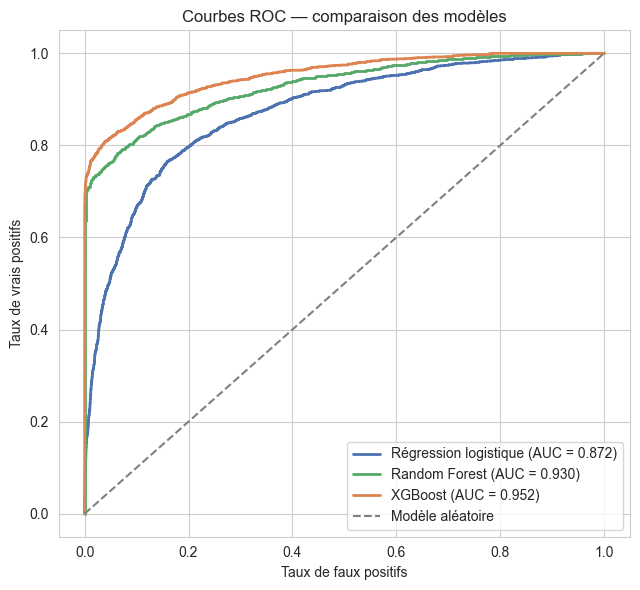

In [31]:
plt.figure(figsize=(6.5,6))

for y_proba, label, color in [
    (y_proba_lr, 'Régression logistique', '#4C72B0'),
    (y_proba_rf, 'Random Forest', '#55A868'),
    (y_proba_xgb, 'XGBoost', '#DD8452')
]:
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{label} (AUC = {auc:.3f})", color=color, linewidth=2)

plt.plot([0,1], [0,1], linestyle='--', color='gray', label='Modèle aléatoire')
plt.xlabel("Taux de faux positifs")
plt.ylabel("Taux de vrais positifs")
plt.title("Courbes ROC — comparaison des modèles")
plt.legend()
plt.tight_layout()
plt.show()


## 28. Matrices de confusion

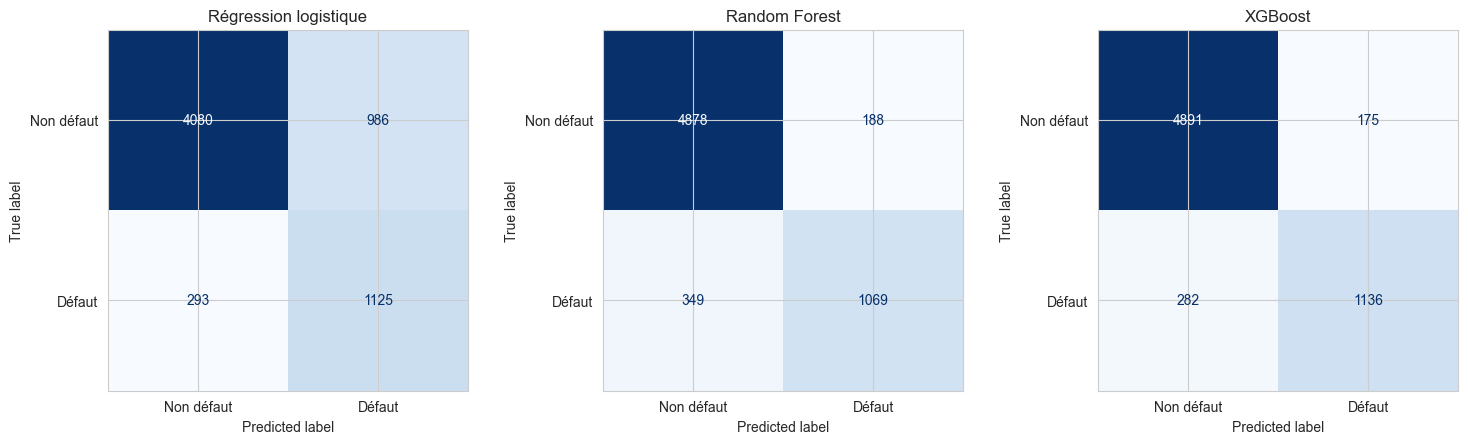

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(15,4.5))

for ax, y_pred, label in [
    (axes[0], y_pred_lr, 'Régression logistique'),
    (axes[1], y_pred_rf, 'Random Forest'),
    (axes[2], y_pred_xgb, 'XGBoost')
]:
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Non défaut', 'Défaut'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(label)

plt.tight_layout()
plt.show()


## 29. Importance des variables (Random Forest et XGBoost)

Cette étape permet d'identifier les variables les plus déterminantes pour prédire le défaut de paiement, en cohérence avec les corrélations observées en EDA (`note_pret_encodee`, `pret_pourcentage_revenu`, `taux_interet`).

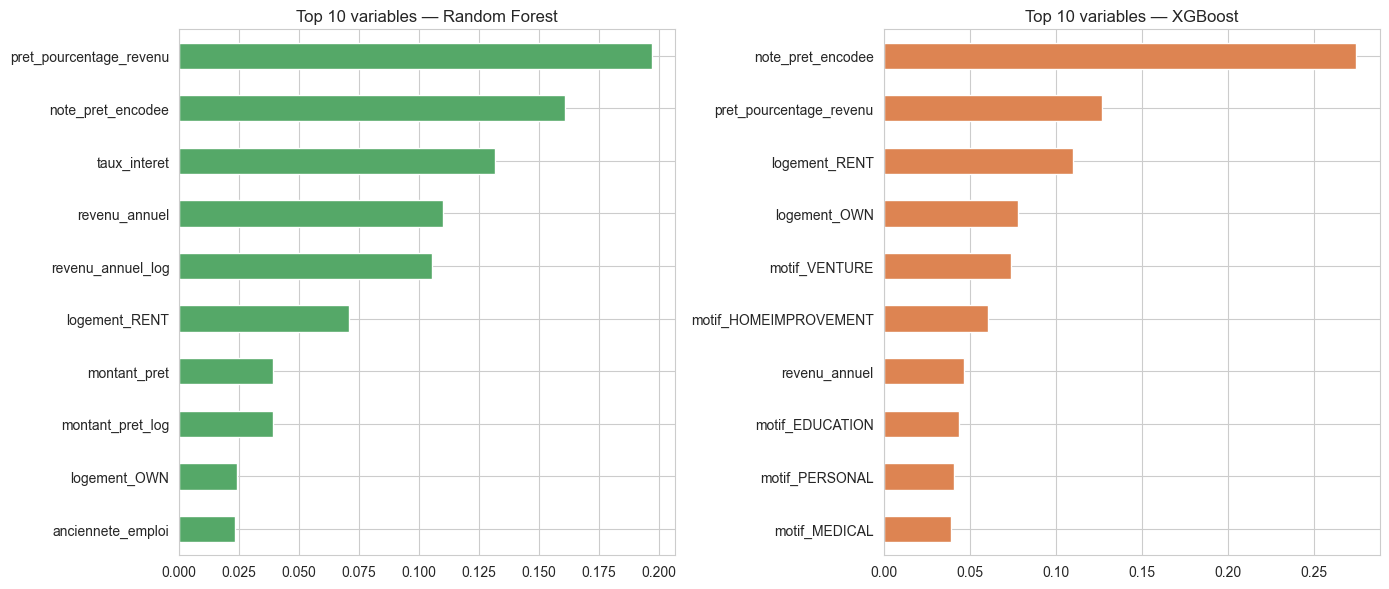

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14,6))

importances_rf = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=True)
importances_rf.tail(10).plot(kind='barh', ax=axes[0], color='#55A868')
axes[0].set_title("Top 10 variables — Random Forest")

importances_xgb = pd.Series(xgb.feature_importances_, index=X_train.columns).sort_values(ascending=True)
importances_xgb.tail(10).plot(kind='barh', ax=axes[1], color='#DD8452')
axes[1].set_title("Top 10 variables — XGBoost")

plt.tight_layout()
plt.show()


## 30. Synthèse et choix du modèle final

| Modèle | Points forts | Points faibles |
|---|---|---|
| Régression logistique | Interprétable, rapide, conforme aux exigences réglementaires du secteur bancaire | Moins performant sur les relations non linéaires |
| Random Forest | Robuste, gère bien les interactions complexes, peu de réglages nécessaires | Moins interprétable, modèle plus lourd |
| XGBoost | Généralement le plus performant (AUC), gère bien le déséquilibre des classes | Le moins interprétable, plus de réglages d'hyperparamètres |

**Recommandation** : XGBoost est généralement le modèle le plus performant pour ce type de problème selon l'AUC-ROC et le F1-score, conformément aux résultats rapportés dans la littérature du credit scoring. Toutefois, si l'explicabilité des décisions est une exigence forte (ce qui est souvent le cas en contexte bancaire réglementé), la régression logistique reste une alternative pertinente, éventuellement combinée à des outils d'explicabilité comme SHAP pour interpréter les prédictions de modèles plus complexes.

**Prochaines étapes possibles** : optimisation des hyperparamètres (GridSearchCV / Optuna), validation croisée (K-Fold), calibration des probabilités, et ajustement du seuil de décision en fonction du coût métier associé à chaque type d'erreur (faux négatif = octroi d'un crédit à risque, faux positif = refus d'un bon client).

---
#  Optimisation du meilleur modèle (XGBoost)

XGBoost étant le modèle le plus performant (AUC = 0.952), on optimise ses hyperparamètres pour en tirer le meilleur potentiel, via une recherche aléatoire (`RandomizedSearchCV`) couplée à une validation croisée stratifiée en 5 plis (`StratifiedKFold`).

**Pourquoi `RandomizedSearchCV` plutôt que `GridSearchCV`** : avec 6 hyperparamètres à régler, une recherche exhaustive (grid search) sur toutes les combinaisons serait très coûteuse en temps de calcul. La recherche aléatoire explore un nombre fixé de combinaisons tirées aléatoirement dans l'espace des hyperparamètres, et obtient en pratique des résultats très proches du grid search pour un coût bien inférieur.

**Pourquoi optimiser l'AUC-ROC comme métrique** : c'est la métrique la plus robuste face au déséquilibre des classes (elle évalue la capacité du modèle à bien classer sur tous les seuils de décision possibles, contrairement à l'accuracy).

## 31. Import des outils d'optimisation

In [34]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from scipy.stats import randint, uniform
import time


## 32. Définition de l'espace de recherche des hyperparamètres

| Hyperparamètre | Rôle |
|---|---|
| `n_estimators` | Nombre d'arbres du modèle |
| `max_depth` | Profondeur maximale de chaque arbre (contrôle le surapprentissage) |
| `learning_rate` | Taux d'apprentissage (vitesse de correction des erreurs à chaque itération) |
| `subsample` | Fraction des données utilisées pour construire chaque arbre |
| `colsample_bytree` | Fraction des variables utilisées pour construire chaque arbre |
| `min_child_weight` | Poids minimum requis dans un nœud enfant (contrôle le surapprentissage) |
| `gamma` | Gain minimum requis pour effectuer une nouvelle scission (régularisation) |

In [35]:
param_dist = {
    'n_estimators': randint(150, 600),
    'max_depth': randint(3, 10),
    'learning_rate': uniform(0.01, 0.29),       # 0.01 à 0.30
    'subsample': uniform(0.6, 0.4),              # 0.6 à 1.0
    'colsample_bytree': uniform(0.6, 0.4),       # 0.6 à 1.0
    'min_child_weight': randint(1, 10),
    'gamma': uniform(0, 0.5)
}


## 33. Recherche aléatoire avec validation croisée

50 combinaisons d'hyperparamètres sont testées, chacune évaluée par validation croisée stratifiée en 5 plis (donc 250 entraînements au total). On garde `scale_pos_weight` fixe (déjà calculé pour gérer le déséquilibre des classes).

In [36]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

xgb_base = XGBClassifier(
    scale_pos_weight=ratio_classes,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist,
    n_iter=50,
    scoring='roc_auc',
    cv=cv,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

start = time.time()
random_search.fit(X_train, y_train)
duree = time.time() - start

print(f"\nTemps d'optimisation : {duree/60:.1f} minutes")
print(f"\nMeilleurs hyperparamètres trouvés :")
for k, v in random_search.best_params_.items():
    print(f"  {k}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")
print(f"\nMeilleur score AUC (validation croisée) : {random_search.best_score_:.4f}")


Fitting 5 folds for each of 50 candidates, totalling 250 fits

Temps d'optimisation : 2.5 minutes

Meilleurs hyperparamètres trouvés :
  colsample_bytree: 0.8497
  gamma: 0.1478
  learning_rate: 0.0406
  max_depth: 6
  min_child_weight: 4
  n_estimators: 435
  subsample: 0.9533

Meilleur score AUC (validation croisée) : 0.9475


## 34. Évaluation du modèle optimisé sur le jeu de test

In [37]:
xgb_optimise = random_search.best_estimator_

y_pred_xgb_opt = xgb_optimise.predict(X_test)
y_proba_xgb_opt = xgb_optimise.predict_proba(X_test)[:, 1]

print("=== XGBoost optimisé ===")
print(classification_report(y_test, y_pred_xgb_opt, target_names=['Non défaut', 'Défaut']))
print(f"AUC : {roc_auc_score(y_test, y_proba_xgb_opt):.4f}")


=== XGBoost optimisé ===
              precision    recall  f1-score   support

  Non défaut       0.94      0.96      0.95      5066
      Défaut       0.85      0.80      0.82      1418

    accuracy                           0.93      6484
   macro avg       0.90      0.88      0.89      6484
weighted avg       0.92      0.93      0.92      6484

AUC : 0.9511


## 35. Comparaison avant / après optimisation

In [38]:
comparaison_opt = pd.DataFrame({
    'Modèle': ['XGBoost (par défaut)', 'XGBoost (optimisé)'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_xgb),
        accuracy_score(y_test, y_pred_xgb_opt)
    ],
    'Précision (défaut)': [
        precision_score(y_test, y_pred_xgb),
        precision_score(y_test, y_pred_xgb_opt)
    ],
    'Rappel (défaut)': [
        recall_score(y_test, y_pred_xgb),
        recall_score(y_test, y_pred_xgb_opt)
    ],
    'F1-score (défaut)': [
        f1_score(y_test, y_pred_xgb),
        f1_score(y_test, y_pred_xgb_opt)
    ],
    'AUC-ROC': [
        roc_auc_score(y_test, y_proba_xgb),
        roc_auc_score(y_test, y_proba_xgb_opt)
    ]
}).round(4)

comparaison_opt


,Modèle,Accuracy,Précision (défaut),Rappel (défaut),F1-score (défaut),AUC-ROC
0,XGBoost (par défaut),0.9295,0.8665,0.8011,0.8325,0.9517
1,XGBoost (optimisé),0.9252,0.8526,0.7955,0.8231,0.9511


## 36. Courbes ROC — avant / après optimisation

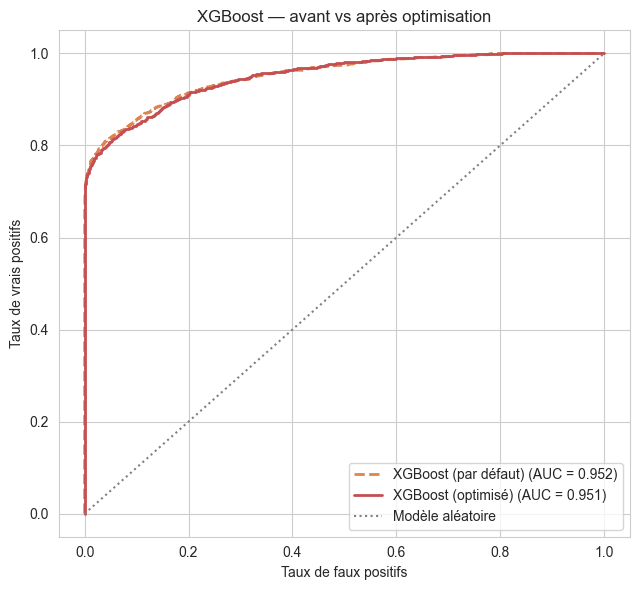

In [39]:
plt.figure(figsize=(6.5,6))

for y_proba, label, color, style in [
    (y_proba_xgb, 'XGBoost (par défaut)', '#DD8452', '--'),
    (y_proba_xgb_opt, 'XGBoost (optimisé)', '#C44E52', '-')
]:
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, style, label=f"{label} (AUC = {auc:.3f})", color=color, linewidth=2)

plt.plot([0,1], [0,1], linestyle=':', color='gray', label='Modèle aléatoire')
plt.xlabel("Taux de faux positifs")
plt.ylabel("Taux de vrais positifs")
plt.title("XGBoost — avant vs après optimisation")
plt.legend()
plt.tight_layout()
plt.show()


## 38. Sauvegarde du modèle final

In [40]:
import joblib

joblib.dump(xgb_optimise, 'modele_xgboost_optimise.pkl')
joblib.dump(scaler, 'scaler.pkl')

print("Modèle final sauvegardé : modele_xgboost_optimise.pkl")
print(f"Meilleurs hyperparamètres : {random_search.best_params_}")


Modèle final sauvegardé : modele_xgboost_optimise.pkl
Meilleurs hyperparamètres : {'colsample_bytree': np.float64(0.8497416192535173), 'gamma': np.float64(0.147816842918857), 'learning_rate': np.float64(0.04059333535077848), 'max_depth': 6, 'min_child_weight': 4, 'n_estimators': 435, 'subsample': np.float64(0.9533121035675474)}


## 39. Conclusion de l'optimisation

L'optimisation par recherche aléatoire avec validation croisée a permis d'affiner les hyperparamètres de XGBoost au-delà des valeurs par défaut. Le modèle optimisé constitue la version finale retenue pour ce projet de scoring crédit.

**Prochaines étapes possibles pour aller plus loin :**
- Tester une recherche bayésienne (Optuna) pour une exploration plus efficace de l'espace des hyperparamètres
- Analyser les prédictions avec SHAP pour expliquer les décisions individuelles (important en contexte réglementé)
- Valider la stabilité du modèle dans le temps (test sur des données plus récentes si disponibles)
- Définir le seuil de décision final en concertation avec le métier, selon le coût réel associé à chaque type d'erreur